In [1]:
from google.colab import drive
import os
import zipfile

# Connecting to your Google Drive
drive.mount('/content/drive')

# Defining the path pointing to your Colab Notebooks folder
zip_path = '/content/drive/MyDrive/Colab Notebooks/IMAGES_PADDED_.zip'
extract_path = '/content/IMAGES_PADDED'

# Unzipping the images into Colab's ultra-fast local storage
if not os.path.exists(extract_path):
    print("Unzipping images... this will take about 30 seconds.")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print("Unzipping complete!")
else:
    print("Images already unzipped for this session!")

Mounted at /content/drive
Unzipping images... this will take about 30 seconds.
Unzipping complete!


In [2]:
import os
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# CONFIGURATION
DATA_CSV = "/content/drive/MyDrive/Colab Notebooks/Master_Processed_Features.xlsx"
IMAGE_DIR = "/content/IMAGES_PADDED/"
BATCH_SIZE = 32

# TRANSFORM FOR EFFICIENTNET-B7
transform = transforms.Compose([
    # Resizing removed because images in IMAGES_PADDED are already 600x600!
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# DYNAMIC COLUMN DETECTION
print("Loading Master Dataset...")
df = pd.read_excel(DATA_CSV)

CATEGORICAL_COLS = [col for col in df.columns if col.endswith('_Encoded') and 'Asset' not in col]
REGRESSION_COLS = ['Overall_Structural_Score']
ASSET_COLS = [col for col in df.columns if col.startswith('Asset_')]

print(f"Detected {len(CATEGORICAL_COLS)} Categorical targets, 1 Regression target, and {len(ASSET_COLS)} Asset targets.")

# SPLITTING THE DATA (80/20)
# This automatically shuffles the entire Excel sheet before splitting
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Training Set: {len(train_df)} images")
print(f"Validation Set: {len(val_df)} images")

# CUSTOM PYTORCH DATASET
class HousingDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.loc[idx, 'Image_Name']
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        cat_targets = {
            col: torch.tensor(self.dataframe.loc[idx, col], dtype=torch.long)
            for col in CATEGORICAL_COLS
        }

        reg_targets = {
            col: torch.tensor(self.dataframe.loc[idx, col], dtype=torch.float32)
            for col in REGRESSION_COLS
        }

        asset_targets = torch.tensor(self.dataframe.loc[idx, ASSET_COLS].values.astype(float), dtype=torch.float32)

        return image, cat_targets, reg_targets, asset_targets

# CREATING DATALOADERS
# shuffle=True guarantees the model sees completely random batches every epoch
train_loader = DataLoader(HousingDataset(train_df, IMAGE_DIR, transform), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(HousingDataset(val_df, IMAGE_DIR, transform), batch_size=BATCH_SIZE, shuffle=False)

print("\n--- Data Pipeline Ready! ---")

Loading Master Dataset...
Detected 8 Categorical targets, 1 Regression target, and 5 Asset targets.
Training Set: 2940 images
Validation Set: 736 images

--- Data Pipeline Ready! ---


In [3]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# NEURAL NETWORK OUTPUT SIZING
cat_class_counts = {}
for col in CATEGORICAL_COLS:
    valid_rows = df[df[col] != -100][col]
    cat_class_counts[col] = int(valid_rows.max()) + 1

num_asset_classes = len(ASSET_COLS)

class HighResHousingModel(nn.Module):
    def __init__(self, cat_class_counts, num_asset_classes):
        super(HighResHousingModel, self).__init__()

        # UPGRADE: Loading the heavy-hitting EfficientNet-B7
        base_model = models.efficientnet_b7(weights='DEFAULT')

        # Freezing the base model to prevent overfitting
        for param in base_model.parameters():
            param.requires_grad = False

        self.features = base_model.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # UPGRADE: EfficientNet stores its hidden size in the classifier block
        hidden_size = base_model.classifier[1].in_features

        self.dropout = nn.Dropout(p=0.5)

        self.cat_heads = nn.ModuleDict({
            col: nn.Linear(hidden_size, num_classes)
            for col, num_classes in cat_class_counts.items()
        })

        self.reg_head = nn.Linear(hidden_size, 1)
        self.asset_head = nn.Linear(hidden_size, num_asset_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)

        outputs = {col: head(x) for col, head in self.cat_heads.items()}
        outputs['Overall_Structural_Score'] = self.reg_head(x).squeeze(dim=-1)
        outputs['Visible_Assets'] = self.asset_head(x)

        return outputs

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HighResHousingModel(cat_class_counts, num_asset_classes).to(DEVICE)
print("\nNeural Network Architecture built successfully!")

Downloading: "https://download.pytorch.org/models/efficientnet_b7_lukemelas-c5b4e57e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b7_lukemelas-c5b4e57e.pth


100%|██████████| 255M/255M [00:01<00:00, 161MB/s]



Neural Network Architecture built successfully!


In [4]:
import copy

# LOSS FUNCTIONS, OPTIMIZER & SCHEDULER
criterion_cat = nn.CrossEntropyLoss(ignore_index=-100)
criterion_reg = nn.MSELoss()
criterion_multilabel = nn.BCEWithLogitsLoss()

LEARNING_RATE = 0.0005
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# UPGRADE: Adding the Learning Rate Scheduler
# If val_loss doesn't improve for 2 epochs (patience=2), reduce LR by a factor of 10 (factor=0.1)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

# TRAINING LOOP WITH EARLY STOPPING
EPOCHS = 50
PATIENCE = 5

best_val_loss = float('inf')
best_model_weights = copy.deepcopy(model.state_dict())
epochs_without_improvement = 0

print(f"\nStarting High-Resolution Training Loop (Max {EPOCHS} Epochs)...")
print(f"Initial Learning Rate: {LEARNING_RATE}")

for epoch in range(EPOCHS):

    # --- TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0
    valid_batches = 0

    for images, cat_targets, reg_targets, asset_targets in train_loader:
        images = images.to(DEVICE)
        cat_targets = {k: v.to(DEVICE) for k, v in cat_targets.items()}
        reg_target = reg_targets['Overall_Structural_Score'].to(DEVICE)
        asset_targets = asset_targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)

        total_loss = torch.tensor(0.0, device=DEVICE)

        for col in CATEGORICAL_COLS:
            cat_loss = criterion_cat(outputs[col], cat_targets[col])
            if not torch.isnan(cat_loss): total_loss += cat_loss

        valid_reg_mask = reg_target != -100.0
        if valid_reg_mask.sum() > 0:
            reg_loss = criterion_reg(
                outputs['Overall_Structural_Score'][valid_reg_mask],
                reg_target[valid_reg_mask]
            )
            if not torch.isnan(reg_loss): total_loss += reg_loss

        asset_loss = criterion_multilabel(outputs['Visible_Assets'], asset_targets)
        if not torch.isnan(asset_loss): total_loss += asset_loss

        if torch.isnan(total_loss) or total_loss == 0.0:
            optimizer.zero_grad()
            continue

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        running_train_loss += total_loss.item()
        valid_batches += 1

    avg_train_loss = running_train_loss / max(1, valid_batches)

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    valid_val_batches = 0

    with torch.no_grad():
        for images, cat_targets, reg_targets, asset_targets in val_loader:
            images = images.to(DEVICE)
            cat_targets = {k: v.to(DEVICE) for k, v in cat_targets.items()}
            reg_target = reg_targets['Overall_Structural_Score'].to(DEVICE)
            asset_targets = asset_targets.to(DEVICE)

            outputs = model(images)
            val_loss = torch.tensor(0.0, device=DEVICE)

            for col in CATEGORICAL_COLS:
                c_loss = criterion_cat(outputs[col], cat_targets[col])
                if not torch.isnan(c_loss): val_loss += c_loss

            valid_reg_mask = reg_target != -100.0
            if valid_reg_mask.sum() > 0:
                r_loss = criterion_reg(
                    outputs['Overall_Structural_Score'][valid_reg_mask],
                    reg_target[valid_reg_mask]
                )
                if not torch.isnan(r_loss): val_loss += r_loss

            a_loss = criterion_multilabel(outputs['Visible_Assets'], asset_targets)
            if not torch.isnan(a_loss): val_loss += a_loss

            if not torch.isnan(val_loss):
                running_val_loss += val_loss.item()
                valid_val_batches += 1

    avg_val_loss = running_val_loss / max(1, valid_val_batches)
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # UPGRADE: Step the scheduler with the current validation loss
    scheduler.step(avg_val_loss)

    # --- EARLY STOPPING LOGIC ---
    if avg_val_loss < best_val_loss:
        print(f"   🌟 New best model found! (Val Loss dropped from {best_val_loss:.4f} to {avg_val_loss:.4f})")
        best_val_loss = avg_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        print(f"   ⚠️ No improvement for {epochs_without_improvement} epoch(s).")

        if epochs_without_improvement >= PATIENCE:
            print(f"\n🛑 Early Stopping Triggered! Halting training to prevent overfitting.")
            break

# Loading the absolute best weights back into the model before saving
print("\nLoading the best weights back into the model...")
model.load_state_dict(best_model_weights)

print("Training Complete! Saving Masked High-Resolution model to Google Drive...")
torch.save(model.state_dict(), "/content/drive/MyDrive/Colab Notebooks/highres_housing_model.pth")


Starting High-Resolution Training Loop (Max 50 Epochs)...
Initial Learning Rate: 0.0005
Epoch [01/50] - Train Loss: 8.9676 | Val Loss: 8.5876
   🌟 New best model found! (Val Loss dropped from inf to 8.5876)
Epoch [02/50] - Train Loss: 6.7193 | Val Loss: 6.2388
   🌟 New best model found! (Val Loss dropped from 8.5876 to 6.2388)
Epoch [03/50] - Train Loss: 5.8680 | Val Loss: 5.4647
   🌟 New best model found! (Val Loss dropped from 6.2388 to 5.4647)
Epoch [04/50] - Train Loss: 5.3285 | Val Loss: 5.1079
   🌟 New best model found! (Val Loss dropped from 5.4647 to 5.1079)
Epoch [05/50] - Train Loss: 4.8841 | Val Loss: 4.8459
   🌟 New best model found! (Val Loss dropped from 5.1079 to 4.8459)
Epoch [06/50] - Train Loss: 4.6681 | Val Loss: 4.6658
   🌟 New best model found! (Val Loss dropped from 4.8459 to 4.6658)
Epoch [07/50] - Train Loss: 4.4258 | Val Loss: 4.5173
   🌟 New best model found! (Val Loss dropped from 4.6658 to 4.5173)
Epoch [08/50] - Train Loss: 4.2904 | Val Loss: 4.3880
   🌟 N

In [5]:
import torch

def run_vram_stress_test(model, train_loader, device):
    print("🚀 Initiating VRAM Stress Test (Full Forward & Backward Pass)...")

    # Ensure memory tracking is reset
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    # Grabbing a single batch of real data
    images, cat_targets, reg_targets, asset_targets = next(iter(train_loader))

    # Moving to GPU
    images = images.to(device)

    # Dummy optimizer for the test
    test_optimizer = optim.Adam(model.parameters(), lr=0.001)
    test_optimizer.zero_grad()

    try:
        # 1. Forward Pass (Stores activations)
        outputs = model(images)

        # Generating a dummy loss just to force the backward math
        dummy_loss = outputs['Overall_Structural_Score'].sum()

        # 2. Backward Pass (Calculates gradients for 30M parameters!)
        dummy_loss.backward()

        # 3. Optimizer Step (Stores momentum averages)
        test_optimizer.step()

        # Measuring peak memory
        peak_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
        total_vram_mb = torch.cuda.get_device_properties(device).total_memory / (1024 ** 2)

        print("\n✅ STRESS TEST PASSED! The GPU survived.")
        print(f"📊 Peak VRAM Used : {peak_mb:.1f} MB")
        print(f"💽 Total GPU VRAM : {total_vram_mb:.1f} MB")
        print(f"📉 Utilization    : {(peak_mb/total_vram_mb)*100:.1f}%")

        if (peak_mb/total_vram_mb) > 0.90:
            print("\n⚠️ WARNING: You are dangerously close to crashing. Consider lowering BATCH_SIZE.")
        else:
            print("\n🟢 You have plenty of memory! Proceed to full training.")

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print("\n💥 CRASH! CUDA Out Of Memory.")
            print("The unfrozen model is too big for your current BATCH_SIZE.")
            print("Solution: Go back to Cell 2 and cut BATCH_SIZE in half.")
        else:
            raise e

# Running the test!
run_vram_stress_test(model, train_loader, DEVICE)

🚀 Initiating VRAM Stress Test (Full Forward & Backward Pass)...

✅ STRESS TEST PASSED! The GPU survived.
📊 Peak VRAM Used : 5349.9 MB
💽 Total GPU VRAM : 14912.7 MB
📉 Utilization    : 35.9%

🟢 You have plenty of memory! Proceed to full training.


In [6]:
import torch.nn.functional as F
from PIL import Image, ImageOps # ⬅️ ADDED ImageOps HERE

# THE TRANSLATOR DICTIONARIES
REVERSE_MAPS = {
    'Image_Context_Encoded': {
        0: 'Exterior_House_Building',
        1: 'Interior_Flat_or_Room',
        2: 'Invalid_or_Unviewable'
    },
    'Housing_Category_Encoded': {0: 'Kutcha', 1: 'Semi-Pucca', 2: 'Pucca', 3: 'Premium'},
    'Ext_Stories_Encoded': {0: 'One Storied', 1: 'Two Storied', 2: 'Three Storied', 3: 'Four Storied', 4: 'Five Storied', 5: 'Six Storied', 6: 'Seven Storied', 7: 'Eight Storied', 8: 'Nine Storied', 9: 'Ten Storied'},
    'Ext_Roof_Type_Encoded': {0: 'Thatch/Tarpaulin', 1: 'Corrugated Tin/Metal', 2: 'Khaprail', 3: 'Asbestos', 4: 'Concrete'},
    'Ext_Wall_Type_Encoded': {0: 'Mud/Makeshift', 1: 'Exposed Brick', 2: 'Finished Concrete/Plaster'},
    'Ext_Structural_Condition_Encoded': {0: 'Dilapidated', 1: 'Poor', 2: 'Average', 3: 'Excellent'},
    'Int_Floor_Material_Encoded': {0: 'Mud/Earth', 1: 'Cement/Concrete', 2: 'Tiles/Marble'},
    'Int_Wall_Finish_Encoded': {0: 'Mud', 1: 'Bare_Brick', 2: 'Raw_Plaster', 3: 'Painted', 4: 'Tiles'}
}

# LOADING THE SAVED BRAIN FROM DRIVE
print("Loading model weights...")
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/highres_housing_model.pth"))
model.eval()

# CHOOSING THE TEST IMAGE
# Note: Ensure this file actually exists in the folder!
TEST_IMAGE_PATH = "/content/drive/MyDrive/Colab Notebooks/stock-photo-vadodara-gujarat-indian-house-and-car-2346806311.jpg"

def analyze_house(image_path):
    print(f"\n--- 🤖 AI STRUCTURAL SURVEY REPORT ---")
    print(f"Analyzing: {image_path}\n")

    try:
        img = Image.open(image_path).convert('RGB')

        # ⬅️ NEW: ON-THE-FLY LETTERBOXING
        # This adds the black bars to make it a perfect 600x600 square without stretching or distorting the house!
        img = ImageOps.pad(img, (600, 600), color=(0, 0, 0))

        input_tensor = transform(img).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            outputs = model(input_tensor)

        print("🏠 CATEGORICAL FEATURES:")
        raw_predictions = {}
        for col in CATEGORICAL_COLS:
            pred_idx = torch.argmax(outputs[col], dim=1).item()
            if col in REVERSE_MAPS and pred_idx in REVERSE_MAPS[col]:
                raw_predictions[col] = REVERSE_MAPS[col][pred_idx]
            else:
                raw_predictions[col] = f"Class Index {pred_idx}"

        context = raw_predictions.get('Image_Context_Encoded', '')
        if 'Exterior' in context:
            raw_predictions['Int_Floor_Material_Encoded'] = 'N/A'
            raw_predictions['Int_Wall_Finish_Encoded'] = 'N/A'
        elif 'Interior' in context:
            raw_predictions['Ext_Stories_Encoded'] = 'N/A'
            raw_predictions['Ext_Roof_Type_Encoded'] = 'N/A'
            raw_predictions['Ext_Wall_Type_Encoded'] = 'N/A'
            raw_predictions['Ext_Structural_Condition_Encoded'] = 'N/A'

        for col, pred_text in raw_predictions.items():
            clean_col_name = col.replace('_Encoded', '').replace('_', ' ')
            print(f" - {clean_col_name}: {pred_text}")

        print("\n" + "-"*40 + "\n")

        score = outputs['Overall_Structural_Score'].item()
        print("📈 OVERALL STRUCTURAL SCORE:")
        print(f" - Rating: {score:.2f} / 1.00\n")

        print("-" * 40 + "\n")

        print("🧠 INSIDE THE AI'S BRAIN (ASSETS):")
        asset_logits = outputs['Visible_Assets'][0]
        asset_probs = torch.sigmoid(asset_logits).cpu().numpy()

        for asset_name, prob in zip(ASSET_COLS, asset_probs):
            clean_name = asset_name.replace('Asset_', '').replace('_', ' ')

            if prob > 0.50: marker = "✅"
            elif prob > 0.20: marker = "👀"
            else: marker = "❌"

            print(f" - {marker} {clean_name}: {prob:.1%} confidence")

    except FileNotFoundError:
        print(f"❌ Error: Could not find the image at {image_path}")

# RUNNING THE SCAN
analyze_house(TEST_IMAGE_PATH)

Loading model weights...

--- 🤖 AI STRUCTURAL SURVEY REPORT ---
Analyzing: /content/drive/MyDrive/Colab Notebooks/stock-photo-vadodara-gujarat-indian-house-and-car-2346806311.jpg

🏠 CATEGORICAL FEATURES:
 - Image Context: Exterior_House_Building
 - Housing Category: Premium
 - Ext Stories: Three Storied
 - Ext Roof Type: Concrete
 - Ext Wall Type: Finished Concrete/Plaster
 - Ext Structural Condition: Excellent
 - Int Floor Material: N/A
 - Int Wall Finish: N/A

----------------------------------------

📈 OVERALL STRUCTURAL SCORE:
 - Rating: 0.96 / 1.00

----------------------------------------

🧠 INSIDE THE AI'S BRAIN (ASSETS):
 - 👀 AC: 49.0% confidence
 - ✅ Four-Wheeler: 86.4% confidence
 - ❌ Tractor: 0.9% confidence
 - ❌ Truck: 0.5% confidence
 - 👀 Two-Wheeler: 45.1% confidence


Running validation images through the model... Please wait.
Data collection complete! Generating reports...


 📊 REPORT FOR: IMAGE CONTEXT

[ CLASSIFICATION REPORT ]
                         precision    recall  f1-score   support

Exterior_House_Building       0.99      0.99      0.99       500
  Interior_Flat_or_Room       0.98      0.98      0.98       236

               accuracy                           0.99       736
              macro avg       0.99      0.99      0.99       736
           weighted avg       0.99      0.99      0.99       736


[ CONFUSION MATRIX ]


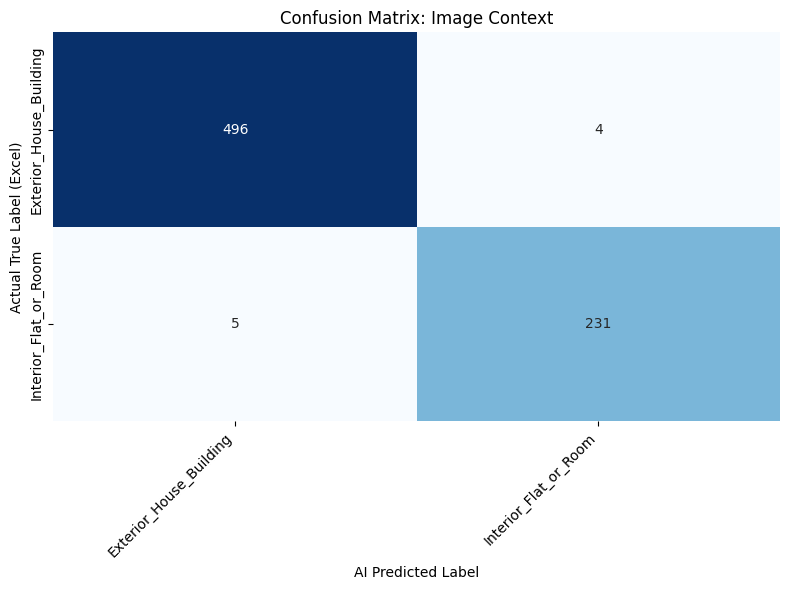


 📊 REPORT FOR: HOUSING CATEGORY

[ CLASSIFICATION REPORT ]
              precision    recall  f1-score   support

      Kutcha       0.71      0.85      0.77        60
  Semi-Pucca       0.63      0.43      0.51        74
       Pucca       0.78      0.83      0.80       425
     Premium       0.69      0.61      0.65       177

    accuracy                           0.74       736
   macro avg       0.70      0.68      0.68       736
weighted avg       0.73      0.74      0.73       736


[ CONFUSION MATRIX ]


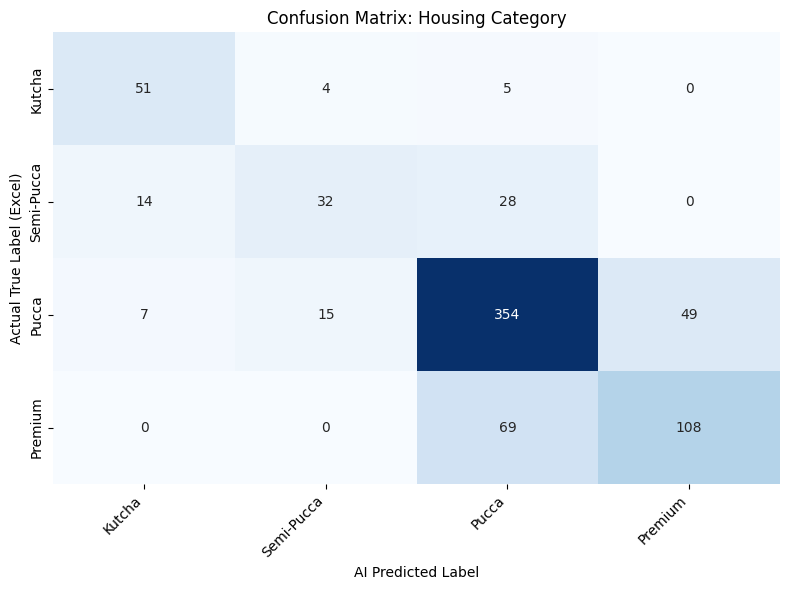


 📊 REPORT FOR: EXT STORIES

[ CLASSIFICATION REPORT ]
               precision    recall  f1-score   support

  One Storied       0.82      0.83      0.83       204
  Two Storied       0.49      0.48      0.48       147
Three Storied       0.60      0.65      0.63       126
 Four Storied       0.10      0.08      0.09        12
 Five Storied       0.50      0.38      0.43         8
  Six Storied       0.00      0.00      0.00         2
Seven Storied       0.00      0.00      0.00         1

     accuracy                           0.65       500
    macro avg       0.36      0.34      0.35       500
 weighted avg       0.64      0.65      0.65       500


[ CONFUSION MATRIX ]


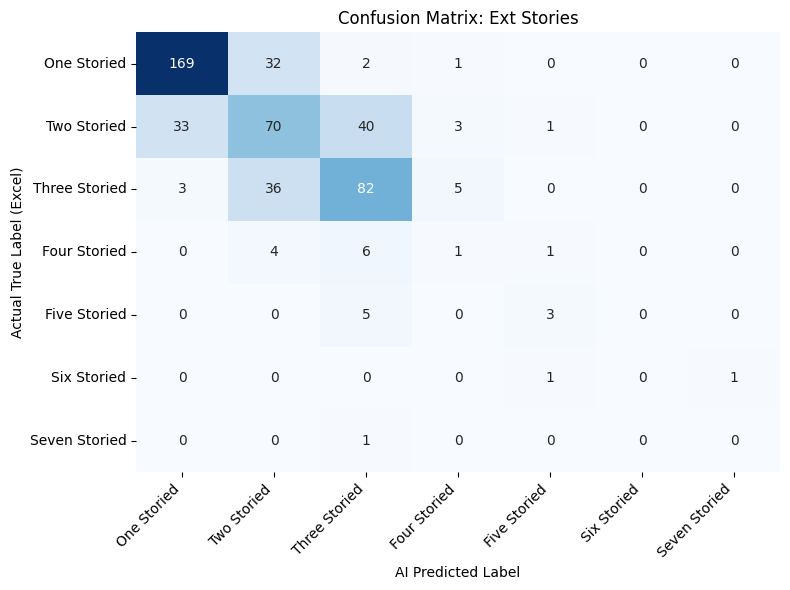


 📊 REPORT FOR: EXT ROOF TYPE

[ CLASSIFICATION REPORT ]
                      precision    recall  f1-score   support

    Thatch/Tarpaulin       0.52      0.64      0.57        25
Corrugated Tin/Metal       0.79      0.35      0.49        31
            Khaprail       0.62      0.69      0.66        36
            Asbestos       0.48      0.38      0.43        26
            Concrete       0.94      0.97      0.95       382

            accuracy                           0.86       500
           macro avg       0.67      0.61      0.62       500
        weighted avg       0.86      0.86      0.85       500


[ CONFUSION MATRIX ]


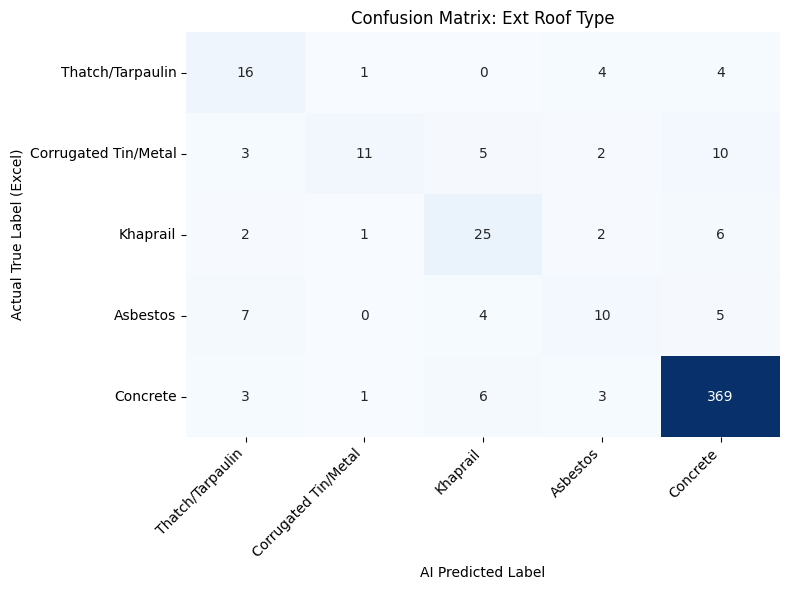


 📊 REPORT FOR: EXT WALL TYPE

[ CLASSIFICATION REPORT ]
                           precision    recall  f1-score   support

            Mud/Makeshift       0.59      0.71      0.64        34
            Exposed Brick       0.67      0.50      0.57        48
Finished Concrete/Plaster       0.95      0.96      0.95       417

                 accuracy                           0.90       499
                macro avg       0.73      0.72      0.72       499
             weighted avg       0.90      0.90      0.90       499


[ CONFUSION MATRIX ]


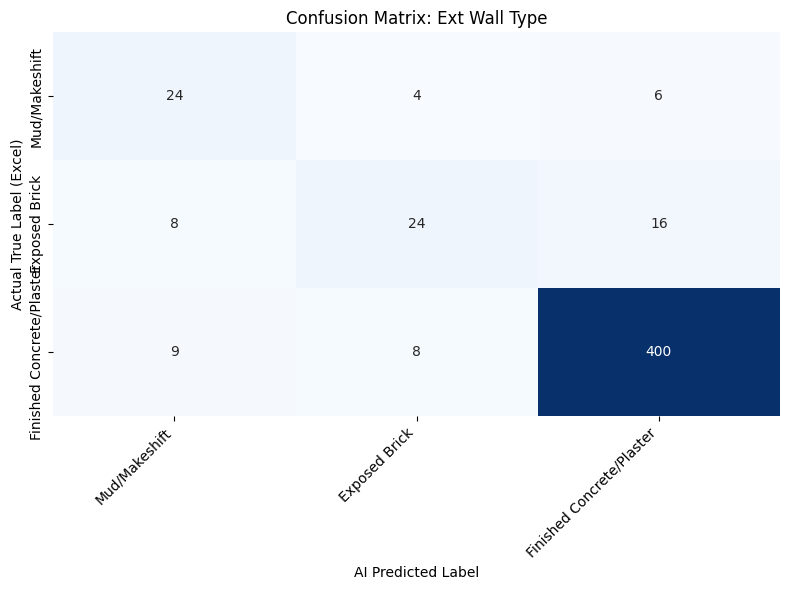


 📊 REPORT FOR: EXT STRUCTURAL CONDITION

[ CLASSIFICATION REPORT ]
              precision    recall  f1-score   support

 Dilapidated       0.00      0.00      0.00         6
        Poor       0.53      0.57      0.55        82
     Average       0.63      0.46      0.53       206
   Excellent       0.83      0.92      0.87       442

    accuracy                           0.75       736
   macro avg       0.50      0.49      0.49       736
weighted avg       0.73      0.75      0.73       736


[ CONFUSION MATRIX ]


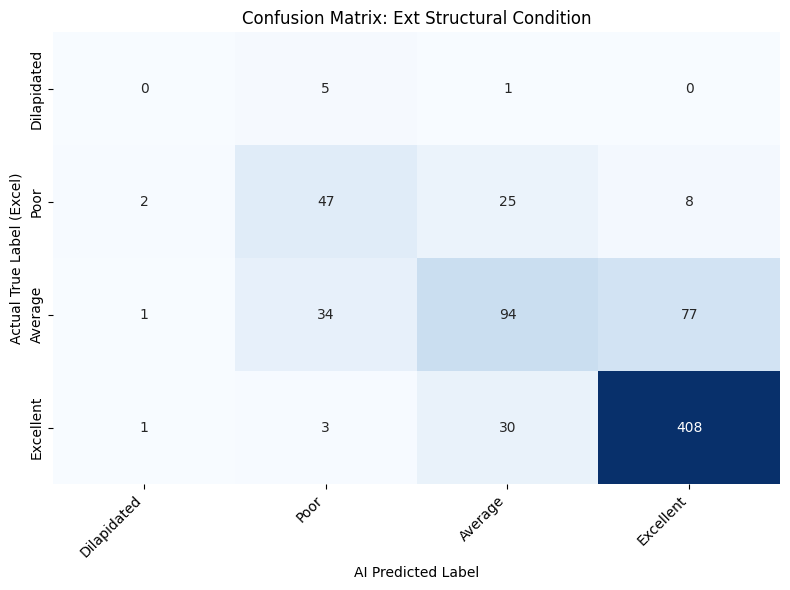


 📊 REPORT FOR: INT FLOOR MATERIAL

[ CLASSIFICATION REPORT ]
                 precision    recall  f1-score   support

      Mud/Earth       0.95      0.88      0.91        41
Cement/Concrete       0.85      0.80      0.82       102
   Tiles/Marble       0.81      0.88      0.85        93

       accuracy                           0.85       236
      macro avg       0.87      0.85      0.86       236
   weighted avg       0.85      0.85      0.85       236


[ CONFUSION MATRIX ]


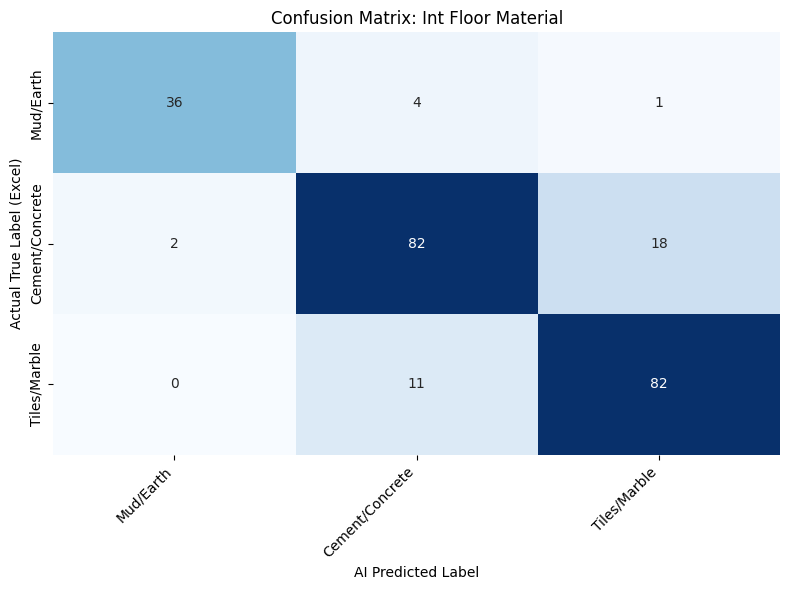


 📊 REPORT FOR: INT WALL FINISH

[ CLASSIFICATION REPORT ]
              precision    recall  f1-score   support

         Mud       0.95      0.97      0.96        37
  Bare_Brick       0.95      0.95      0.95        22
 Raw_Plaster       0.88      0.92      0.90        49
     Painted       0.91      0.85      0.88        92
       Tiles       0.82      0.89      0.85        36

    accuracy                           0.90       236
   macro avg       0.90      0.92      0.91       236
weighted avg       0.90      0.90      0.90       236


[ CONFUSION MATRIX ]


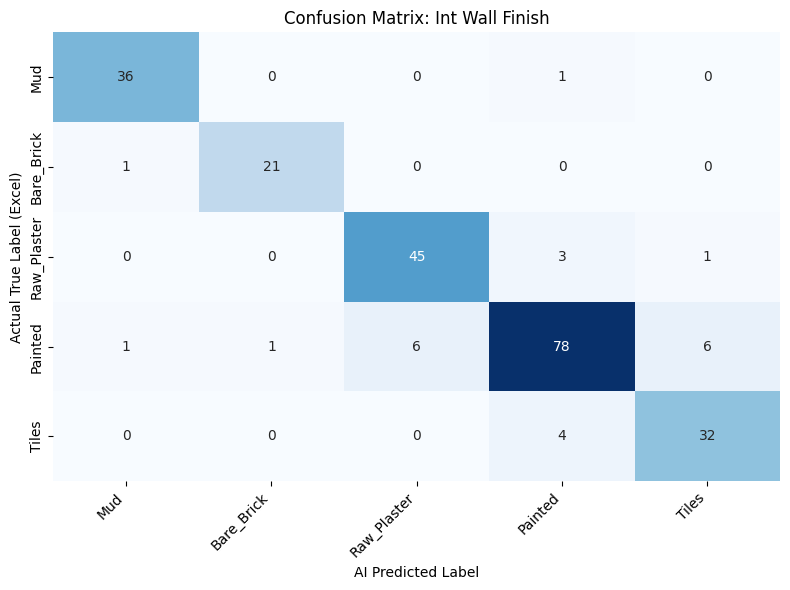

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

# INITIALIZATION
model.eval() # Ensure model is locked in evaluation mode

# Dictionaries to store the ground truth and the AI's guesses
all_true = {col: [] for col in CATEGORICAL_COLS}
all_pred = {col: [] for col in CATEGORICAL_COLS}

print("Running validation images through the model... Please wait.")

# GATHERING PREDICTIONS
with torch.no_grad():
    for images, cat_targets, reg_targets, asset_targets in val_loader:
        images = images.to(DEVICE)
        outputs = model(images)

        for col in CATEGORICAL_COLS:
            # Grabbing the highest probability prediction index
            preds = torch.argmax(outputs[col], dim=1).cpu().numpy()
            trues = cat_targets[col].cpu().numpy()

            # Filtering out missing/padding data (-100)
            valid_mask = trues != -100

            all_pred[col].extend(preds[valid_mask])
            all_true[col].extend(trues[valid_mask])

print("Data collection complete! Generating reports...\n")

# GENERATING THE EVALUATION REPORTS
for col in CATEGORICAL_COLS:
    clean_name = col.replace('_Encoded', '').replace('_', ' ')
    print(f"\n" + "="*50)
    print(f" 📊 REPORT FOR: {clean_name.upper()}")
    print("="*50)

    y_true = all_true[col]
    y_pred = all_pred[col]

    if len(y_true) == 0:
        print("No valid validation data for this category.")
        continue

    # Getting the human-readable names for the report if they exist
    unique_labels = sorted(list(set(y_true + y_pred)))
    target_names = [REVERSE_MAPS[col].get(i, f"Class {i}") for i in unique_labels] if col in REVERSE_MAPS else None

    # --- A. CLASSIFICATION REPORT ---
    print("\n[ CLASSIFICATION REPORT ]")
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

    # --- B. CONFUSION MATRIX HEATMAP ---
    print("\n[ CONFUSION MATRIX ]")
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names if target_names else "auto",
                yticklabels=target_names if target_names else "auto",
                cbar=False)

    plt.title(f'Confusion Matrix: {clean_name}')
    plt.ylabel('Actual True Label (Excel)')
    plt.xlabel('AI Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # 💾 ADDING THIS LINE TO SAVE TO DRIVE (dynamically names the file based on the category!)
    save_path = f"/content/drive/MyDrive/Colab Notebooks/confusion_matrix_{clean_name.replace(' ', '_')}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


 📈 REPORT FOR: OVERALL STRUCTURAL SCORE (REGRESSION)
Mean Absolute Error (MAE): 0.0935 (Average distance from true score)
Root Mean Squared Error (RMSE): 0.1150
R-Squared (R2): 0.4481 (Closer to 1.0 is better)


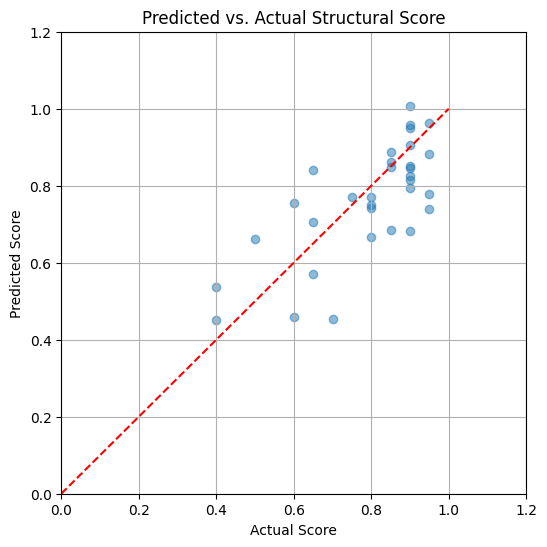

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

all_true_reg = []
all_pred_reg = []

trues_reg = reg_targets['Overall_Structural_Score'].cpu().numpy()
preds_reg = outputs['Overall_Structural_Score'].cpu().numpy()
valid_reg_mask = trues_reg != -100.0

all_true_reg.extend(trues_reg[valid_reg_mask])
all_pred_reg.extend(preds_reg[valid_reg_mask])

print("\n" + "="*50)
print(" 📈 REPORT FOR: OVERALL STRUCTURAL SCORE (REGRESSION)")
print("="*50)

if len(all_true_reg) > 0:
    mae = mean_absolute_error(all_true_reg, all_pred_reg)
    rmse = np.sqrt(mean_squared_error(all_true_reg, all_pred_reg))
    r2 = r2_score(all_true_reg, all_pred_reg)

    print(f"Mean Absolute Error (MAE): {mae:.4f} (Average distance from true score)")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-Squared (R2): {r2:.4f} (Closer to 1.0 is better)")

    # Simple Scatter Plot to visualize the errors
    plt.figure(figsize=(6, 6))
    plt.scatter(all_true_reg, all_pred_reg, alpha=0.5)
    plt.plot([0, 1], [0, 1], 'r--') # Perfect prediction diagonal line
    plt.title('Predicted vs. Actual Structural Score')
    plt.xlabel('Actual Score')
    plt.ylabel('Predicted Score')
    plt.xlim(0, 1.2)
    plt.ylim(0, 1.2)
    plt.grid(True)
    plt.savefig('structural_score_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No valid validation data for Regression.")

Loading model weights...

--- 🤖 AI STRUCTURAL SURVEY REPORT ---
Analyzing: /content/drive/MyDrive/Colab Notebooks/stock-photo-vadodara-gujarat-indian-house-and-car-2346806311.jpg

🏠 CATEGORICAL FEATURES:
 - Image Context: Exterior_House_Building
 - Housing Category: Premium
 - Ext Stories: Three Storied
 - Ext Roof Type: Concrete
 - Ext Wall Type: Finished Concrete/Plaster
 - Ext Structural Condition: Excellent
 - Int Floor Material: Cement/Concrete
 - Int Wall Finish: Tiles

----------------------------------------

📈 OVERALL STRUCTURAL SCORE:
 - Rating: 0.96 / 1.00

----------------------------------------

🧠 INSIDE THE AI'S BRAIN (ASSETS):
 - 👀 AC: 49.0% confidence
 - ✅ Four-Wheeler: 86.4% confidence
 - ❌ Tractor: 0.9% confidence
 - ❌ Truck: 0.5% confidence
 - 👀 Two-Wheeler: 45.1% confidence


🔍 GENERATING GRAD-CAM VISUALIZATIONS...
✅ Image successfully saved to: /content/drive/MyDrive/Colab Notebooks/gradcam_analysis_output.png


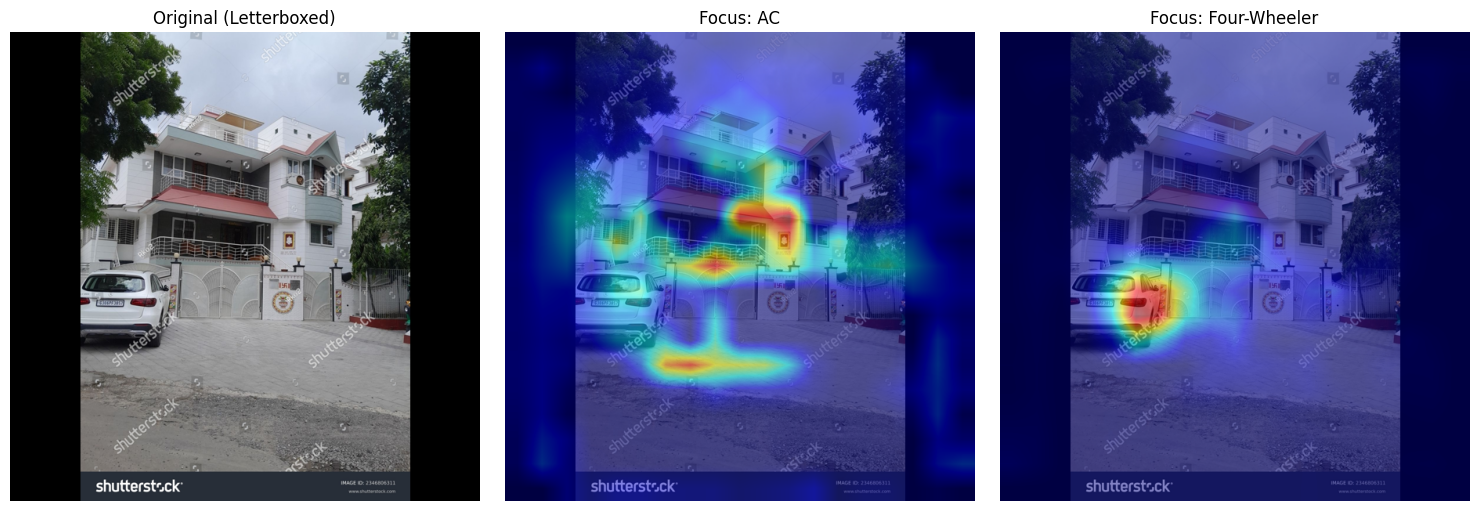

In [9]:
import torch.nn.functional as F
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import numpy as np
import cv2 # OpenCV for heatmap image manipulation

# THE TRANSLATOR DICTIONARIES
REVERSE_MAPS = {
    'Image_Context_Encoded': {
        0: 'Exterior_House_Building',
        1: 'Interior_Flat_or_Room',
        2: 'Invalid_or_Unviewable'
    },
    'Housing_Category_Encoded': {0: 'Kutcha', 1: 'Semi-Pucca', 2: 'Pucca', 3: 'Premium'},
    'Ext_Stories_Encoded': {0: 'One Storied', 1: 'Two Storied', 2: 'Three Storied', 3: 'Four Storied', 4: 'Five Storied', 5: 'Six Storied', 6: 'Seven Storied', 7: 'Eight Storied', 8: 'Nine Storied', 9: 'Ten Storied'},
    'Ext_Roof_Type_Encoded': {0: 'Thatch/Tarpaulin', 1: 'Corrugated Tin/Metal', 2: 'Khaprail', 3: 'Asbestos', 4: 'Concrete'},
    'Ext_Wall_Type_Encoded': {0: 'Mud/Makeshift', 1: 'Exposed Brick', 2: 'Finished Concrete/Plaster'},
    'Ext_Structural_Condition_Encoded': {0: 'Dilapidated', 1: 'Poor', 2: 'Average', 3: 'Excellent'},
    'Int_Floor_Material_Encoded': {0: 'Mud/Earth', 1: 'Cement/Concrete', 2: 'Tiles/Marble'},
    'Int_Wall_Finish_Encoded': {0: 'Mud', 1: 'Bare_Brick', 2: 'Raw_Plaster', 3: 'Painted', 4: 'Tiles'}
}

# LOADING THE SAVED BRAIN FROM DRIVE
print("Loading model weights...")
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/highres_housing_model.pth"))
model.eval()

# GRAD-CAM EXTRACTOR TOOL
class GradCamExtractor:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Attaching hooks to intercept the data flowing through the layer
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def __call__(self, x):
        return self.model(x)

# Targeting the very last convolutional block of EfficientNet-B7
# This is where the AI holds the most complex visual concepts before making a final decision
grad_cam = GradCamExtractor(model, model.features[-1])

# CHOOSING OUR TEST IMAGE
TEST_IMAGE_PATH = "/content/drive/MyDrive/Colab Notebooks/stock-photo-vadodara-gujarat-indian-house-and-car-2346806311.jpg"

def analyze_house(image_path):
    print(f"\n--- 🤖 AI STRUCTURAL SURVEY REPORT ---")
    print(f"Analyzing: {image_path}\n")

    try:
        raw_img = Image.open(image_path).convert('RGB')

        # On-the-fly letterboxing
        padded_img = ImageOps.pad(raw_img, (600, 600), color=(0, 0, 0))
        input_tensor = transform(padded_img).unsqueeze(0).to(DEVICE)

        # PHASE 1: STANDARD REPORT (NO GRADIENTS)
        with torch.no_grad():
            outputs = model(input_tensor)

        print("🏠 CATEGORICAL FEATURES:")
        raw_predictions = {}
        for col in CATEGORICAL_COLS:
            pred_idx = torch.argmax(outputs[col], dim=1).item()
            if col in REVERSE_MAPS and pred_idx in REVERSE_MAPS[col]:
                raw_predictions[col] = REVERSE_MAPS[col][pred_idx]
            else:
                raw_predictions[col] = f"Class Index {pred_idx}"

        for col, pred_text in raw_predictions.items():
            clean_col_name = col.replace('_Encoded', '').replace('_', ' ')
            print(f" - {clean_col_name}: {pred_text}")

        print("\n" + "-"*40 + "\n")

        # Clamping the regression score so it doesn't exceed 1.00
        score = outputs['Overall_Structural_Score'].item()
        score = max(0.0, min(1.0, score))
        print("📈 OVERALL STRUCTURAL SCORE:")
        print(f" - Rating: {score:.2f} / 1.00\n")

        print("-" * 40 + "\n")

        print("🧠 INSIDE THE AI'S BRAIN (ASSETS):")
        asset_logits_no_grad = outputs['Visible_Assets'][0]
        asset_probs = torch.sigmoid(asset_logits_no_grad).cpu().numpy()

        for asset_name, prob in zip(ASSET_COLS, asset_probs):
            clean_name = asset_name.replace('Asset_', '').replace('_', ' ')
            if prob > 0.50: marker = "✅"
            elif prob > 0.20: marker = "👀"
            else: marker = "❌"
            print(f" - {marker} {clean_name}: {prob:.1%} confidence")

        print("\n" + "="*40 + "\n")
        print("🔍 GENERATING GRAD-CAM VISUALIZATIONS...")

        # PHASE 2: GRAD-CAM VISUALIZATION
        # We need to find the specific column indexes for AC and Four-Wheeler
        targets_to_visualize = ['AC', 'Four-Wheeler']

        # Converting the padded PIL image to a numpy array for OpenCV overlay later
        img_np = np.array(padded_img)
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        img_np = np.float32(img_np) / 255.0

        plt.figure(figsize=(15, 5))

        # Ploting Original Image First
        plt.subplot(1, len(targets_to_visualize) + 1, 1)
        plt.imshow(padded_img)
        plt.title("Original (Letterboxed)")
        plt.axis('off')

        for i, target_name in enumerate(targets_to_visualize):
            try:
                # Find the index of the asset dynamically
                asset_idx = next(idx for idx, col in enumerate(ASSET_COLS) if target_name in col)
                input_tensor.requires_grad_(True)
                # Zero out gradients from previous runs
                model.zero_grad()

                # Forward pass WITH gradients enabled
                outputs = grad_cam(input_tensor)
                asset_logits = outputs['Visible_Assets'][0]

                # Target the specific logit (e.g., the exact neuron for "Four-Wheeler")
                target_logit = asset_logits[asset_idx]

                # Backward pass to trace which pixels influenced this exact neuron
                target_logit.backward(retain_graph=True)

                # Calculate the heatmap
                gradients = grad_cam.gradients.cpu().data.numpy()[0]
                activations = grad_cam.activations.cpu().data.numpy()[0]

                # Global average pool the gradients
                weights = np.mean(gradients, axis=(1, 2))

                # Weight the activations
                cam = np.zeros(activations.shape[1:], dtype=np.float32)
                for j, w in enumerate(weights):
                    cam += w * activations[j, :, :]

                # Apply ReLU to only keep pixels that *positively* influenced the decision
                cam = np.maximum(cam, 0)

                # Resize the small heatmap back to 600x600 and normalize to 0-1
                cam = cv2.resize(cam, (600, 600))
                cam = cam - np.min(cam)
                cam = cam / np.max(cam)

                # Overlay heatmap on the original image
                heatmap_img = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
                heatmap_img = np.float32(heatmap_img) / 255.0
                overlay = heatmap_img + img_np
                overlay = overlay / np.max(overlay)

                # Convert back to RGB for matplotlib
                overlay = cv2.cvtColor(np.uint8(255 * overlay), cv2.COLOR_BGR2RGB)

                # Plot it!
                plt.subplot(1, len(targets_to_visualize) + 1, i + 2)
                plt.imshow(overlay)
                plt.title(f"Focus: {target_name}")
                plt.axis('off')

            except StopIteration:
                print(f"Warning: Could not find '{target_name}' in ASSET_COLS.")

        plt.tight_layout()

        # 💾 ADDING THIS LINE TO SAVE TO DRIVE
        save_path = "/content/drive/MyDrive/Colab Notebooks/gradcam_analysis_output.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Image successfully saved to: {save_path}")

        plt.show()

    except FileNotFoundError:
        print(f"❌ Error: Could not find the image at {image_path}")

# RUNNING THE SCAN
analyze_house(TEST_IMAGE_PATH)